# FH SVM — Jaundice Detection – Forehead Region V1 (NJN)


In [1]:
!pip -q install opencv-python numpy pandas matplotlib seaborn scikit-learn scipy tqdm

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, skew, kurtosis

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    roc_auc_score, accuracy_score, precision_score, recall_score,
    f1_score, brier_score_loss
)
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.utils import resample

from google.colab import drive

In [3]:
# Google Drive mount
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# DATASET PATH
dataset_path = "/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN"

img_exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
all_imgs = []

for ext in img_exts:
    all_imgs += glob.glob(os.path.join(dataset_path, "**", ext), recursive=True)

print("Total images found:", len(all_imgs))
print("Sample paths:", all_imgs[:5])

Total images found: 760
Sample paths: ['/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1000).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1103).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1078).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1024).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (566).jpg']


In [5]:
# LABELING
def infer_label_from_path(p):
    lp = p.lower()
    pos_keys = ["jaundice", "icteric", "positive", "pos", "case", "patient", "affected", "yellow"]
    neg_keys = ["normal", "control", "negative", "neg", "healthy", "non"]

    if any(k in lp for k in pos_keys):
        return 1
    if any(k in lp for k in neg_keys):
        return 0
    return None

pairs = [(p, infer_label_from_path(p)) for p in all_imgs]
pairs = [(p, l) for p, l in pairs if l is not None]

imgs = [p for p, l in pairs]
y_all = np.array([l for p, l in pairs])

print("Labeled images:", len(imgs))
print("Class counts (0=Normal, 1=Jaundice):", np.bincount(y_all))

Labeled images: 760
Class counts (0=Normal, 1=Jaundice): [560 200]


In [6]:
# FOREHEAD ROI (REVISED: head-aware heuristic)
def get_forehead_box(img_bgr):
    h, w = img_bgr.shape[:2]

    # Whole-image skin mask to find the head/face region instead of using a fixed top-center crop
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 20, 40], dtype=np.uint8)
    upper = np.array([25, 255, 255], dtype=np.uint8)
    mask = cv2.inRange(hsv, lower, upper)

    k = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=2)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)

    candidates = []
    min_area = max(300, int(0.002 * h * w))
    for i in range(1, num_labels):
        x, y, bw, bh, area = stats[i]
        if area >= min_area:
            candidates.append((i, x, y, bw, bh, area))

    if candidates:
        # Pick the highest sufficiently large skin component; this is usually the face/head region
        candidates = sorted(candidates, key=lambda t: (t[2], -t[5]))
        _, x, y, bw, bh, area = candidates[0]

        # Small padding around the detected head box
        pad_x = int(0.08 * bw)
        pad_y = int(0.08 * bh)
        x = max(0, x - pad_x)
        y = max(0, y - pad_y)
        bw = min(w - x, bw + 2 * pad_x)
        bh = min(h - y, bh + 2 * pad_y)

        # Forehead = upper-middle part of the head box
        x1 = max(0, x + int(0.12 * bw))
        x2 = min(w, x + int(0.88 * bw))
        y1 = max(0, y + int(0.02 * bh))
        y2 = min(h, y + int(0.30 * bh))
    else:
        # Fallback if skin detection fails
        x1 = int(0.20 * w)
        x2 = int(0.60 * w)
        y1 = int(0.08 * h)
        y2 = int(0.26 * h)

    # Safety fallback
    if (x2 - x1) < 10 or (y2 - y1) < 10:
        x1 = int(0.20 * w)
        x2 = int(0.60 * w)
        y1 = int(0.08 * h)
        y2 = int(0.26 * h)

    return x1, y1, x2, y2, mask


def extract_forehead_roi(img_bgr):
    x1, y1, x2, y2, _ = get_forehead_box(img_bgr)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None


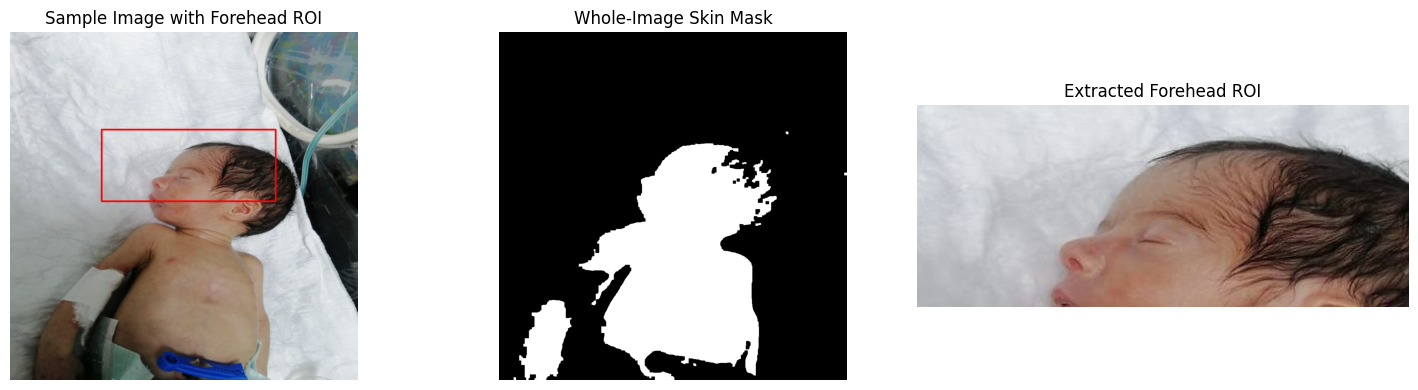

In [7]:
# OPTIONAL: ROI PREVIEW (REVISED)
sample_path = imgs[0]
sample_img = cv2.imread(sample_path)
sample_rgb = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

x1, y1, x2, y2, whole_mask = get_forehead_box(sample_img)

vis = sample_rgb.copy()
cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 0, 0), 3)

roi = extract_forehead_roi(sample_img)
roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(vis)
plt.title("Sample Image with Forehead ROI")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(whole_mask, cmap="gray")
plt.title("Whole-Image Skin Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(roi_rgb)
plt.title("Extracted Forehead ROI")
plt.axis("off")

plt.tight_layout()
plt.show()


In [8]:
# PREPROCESSING
def gray_world_white_balance(img_bgr):
    img = img_bgr.astype(np.float32)
    b, g, r = cv2.split(img)

    mb, mg, mr = np.mean(b), np.mean(g), np.mean(r)
    m = (mb + mg + mr) / 3.0

    b = b * (m / (mb + 1e-6))
    g = g * (m / (mg + 1e-6))
    r = r * (m / (mr + 1e-6))

    out = cv2.merge([b, g, r])
    return np.clip(out, 0, 255).astype(np.uint8)

def normalize_clahe_lab(roi_bgr, clip=2.5):
    lab = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2LAB)
    L, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8, 8))
    L2 = clahe.apply(L)

    lab2 = cv2.merge([L2, a, b])
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)

def preprocess_roi(roi_bgr):
    roi_bgr = gray_world_white_balance(roi_bgr)
    roi_bgr = normalize_clahe_lab(roi_bgr, clip=2.5)
    return roi_bgr

In [9]:
# SKIN MASK
def skin_mask_hsv(roi_bgr):
    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)

    lower = np.array([0, 20, 40], dtype=np.uint8)
    upper = np.array([25, 255, 255], dtype=np.uint8)

    mask = cv2.inRange(hsv, lower, upper)

    k = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=1)

    return mask

In [10]:
# FEATURE EXTRACTION
def masked_stats(channel, mask):
    vals = channel[mask == 255].astype(np.float32)

    if vals.size < 30:
        return (np.nan,) * 6

    return (
        float(np.mean(vals)),
        float(np.std(vals)),
        float(np.median(vals)),
        float(skew(vals)),
        float(kurtosis(vals)),
        float(np.percentile(vals, 90))
    )

def extract_features_from_roi(roi_bgr):
    roi_bgr = preprocess_roi(roi_bgr)
    mask = skin_mask_hsv(roi_bgr)

    if np.sum(mask == 255) < 200:
        mask = np.ones(roi_bgr.shape[:2], dtype=np.uint8) * 255

    roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)

    R = roi_rgb[:, :, 0]
    G = roi_rgb[:, :, 1]
    B = roi_rgb[:, :, 2]

    Rm, Rs, _, _, _, R90 = masked_stats(R, mask)
    Gm, Gs, _, _, _, G90 = masked_stats(G, mask)
    Bm, Bs, _, _, _, B90 = masked_stats(B, mask)

    ygi = float((Rm + Gm) / (Bm + 1e-6))
    r_over_b = float(Rm / (Bm + 1e-6))
    g_over_b = float(Gm / (Bm + 1e-6))
    rg_balance = float((Rm - Gm) / (Rm + Gm + 1e-6))

    denom = (Rm + Gm + Bm + 1e-6)
    r_ch = float(Rm / denom)
    g_ch = float(Gm / denom)
    b_ch = float(Bm / denom)

    hsv = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
    H = hsv[:, :, 0]
    S = hsv[:, :, 1]
    V = hsv[:, :, 2]

    Hm, _, _, _, _, _ = masked_stats(H, mask)
    Sm, _, _, _, _, _ = masked_stats(S, mask)
    Vm, Vs, _, _, _, _ = masked_stats(V, mask)

    Hvals = H[mask == 255]
    if Hvals.size > 30:
        hist, _ = np.histogram(Hvals, bins=18, range=(0, 180))
        hue_peak = float(np.argmax(hist))
    else:
        hue_peak = np.nan

    lab = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2LAB).astype(np.float32)
    L = lab[:, :, 0]
    a = lab[:, :, 1]
    b = lab[:, :, 2]

    Lm, _, _, _, _, _ = masked_stats(L, mask)
    am, _, _, _, _, _ = masked_stats(a, mask)
    bm, _, _, _, _, b90 = masked_stats(b, mask)

    bvals = b[mask == 255]
    yellow_prop = float(np.mean(bvals > np.percentile(bvals, 75))) if bvals.size > 30 else np.nan

    feats = {
        "R_mean": Rm, "G_mean": Gm, "B_mean": Bm,
        "R_std": Rs, "G_std": Gs, "B_std": Bs,
        "R_p90": R90, "G_p90": G90, "B_p90": B90,
        "YGI": ygi,
        "R_over_B": r_over_b,
        "G_over_B": g_over_b,
        "RG_balance": rg_balance,
        "r_ch": r_ch, "g_ch": g_ch, "b_ch": b_ch,
        "H_mean": Hm, "S_mean": Sm, "V_mean": Vm,
        "V_std": Vs,
        "Hue_peak_bin": hue_peak,
        "L_mean": Lm, "a_mean": am, "Lab_b_mean": bm,
        "Lab_b_p90": b90,
        "yellow_prop": yellow_prop,
    }

    feats["YGI_x_b"] = feats["YGI"] * feats["Lab_b_mean"]
    return feats

In [11]:
# BUILD FOREHEAD FEATURE DATASET
rows = []
failed = 0

for p, label in tqdm(pairs, total=len(pairs)):
    img = cv2.imread(p)

    if img is None:
        failed += 1
        continue

    roi = extract_forehead_roi(img)
    if roi is None:
        failed += 1
        continue

    feats = extract_features_from_roi(roi)
    feats["label"] = int(label)
    feats["path"] = p
    rows.append(feats)

feat_df_forehead = pd.DataFrame(rows)

print("Forehead features shape:", feat_df_forehead.shape)
print("Failed:", failed)
print("Label distribution:")
print(feat_df_forehead["label"].value_counts())

feat_df_forehead.head()

100%|██████████| 760/760 [02:10<00:00,  5.82it/s]

Forehead features shape: (760, 29)
Failed: 0
Label distribution:
label
0    560
1    200
Name: count, dtype: int64


,R_mean,G_mean,B_mean,R_std,G_std,B_std,R_p90,G_p90,B_p90,YGI,...,V_std,Hue_peak_bin,L_mean,a_mean,Lab_b_mean,Lab_b_p90,yellow_prop,YGI_x_b,label,path
0,142.692139,118.133736,105.400917,45.357891,41.837891,39.035332,197.000000,169.0,153.0,2.474607,...,45.357891,1.0,130.436264,135.658539,138.624634,145.0,0.209546,343.041522,0,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...
1,140.716583,133.283096,107.253349,37.735466,38.788330,38.887547,183.000000,177.0,156.0,2.554696,...,37.735466,2.0,140.892929,126.508278,143.144150,149.0,0.216028,365.689753,0,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...
2,134.154312,110.451042,98.346046,50.425636,49.026459,48.775738,199.000000,174.0,162.0,2.487190,...,50.425793,1.0,122.082077,135.667999,138.458054,143.0,0.171258,344.371555,0,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...
3,157.713242,130.946289,125.316078,51.760181,46.349003,45.811523,214.000000,182.0,176.0,2.303452,...,51.760487,0.0,143.928574,137.372818,134.953766,139.0,0.223502,310.859476,0,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...
4,145.889679,121.394920,108.911842,46.213348,41.162308,40.142250,205.099609,175.0,162.0,2.454137,...,46.213348,0.0,133.747955,135.541214,138.452866,143.0,0.231574,339.782319,0,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...


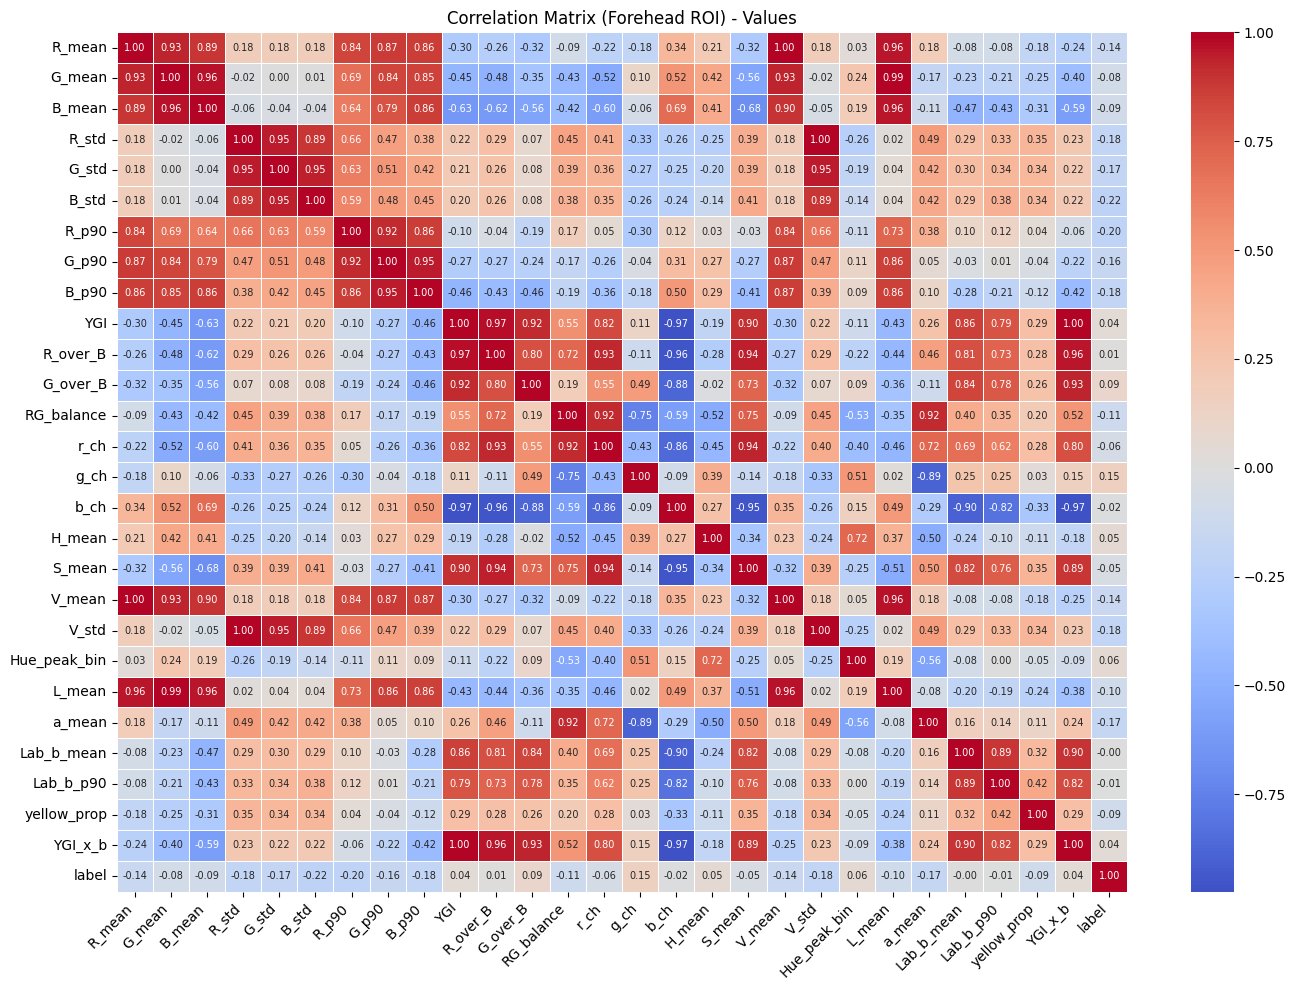

Correlation with label (sorted):
g_ch            0.147
G_over_B        0.090
Hue_peak_bin    0.058
H_mean          0.054
YGI             0.040
YGI_x_b         0.039
R_over_B        0.008
Lab_b_mean     -0.002
Lab_b_p90      -0.006
b_ch           -0.017
S_mean         -0.048
r_ch           -0.059
G_mean         -0.081
B_mean         -0.091
yellow_prop    -0.095
L_mean         -0.096
RG_balance     -0.114
V_mean         -0.144
R_mean         -0.144
G_p90          -0.156
a_mean         -0.170
G_std          -0.173
V_std          -0.180
R_std          -0.181
B_p90          -0.184
R_p90          -0.203
B_std          -0.218
Name: label, dtype: float64


In [12]:
# CORRELATION HEATMAP
corr = feat_df_forehead.drop(columns=["path"]).corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    linewidths=0.5, linecolor="white", annot_kws={"size": 7}
)
plt.title("Correlation Matrix (Forehead ROI) - Values")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

label_corr = corr["label"].drop("label").sort_values(ascending=False)
print("Correlation with label (sorted):")
print(label_corr.round(3))

In [13]:
# T-TEST SIGNIFICANT FEATURES
results = []

for col in feat_df_forehead.columns:
    if col in ["label", "path"]:
        continue

    c0 = feat_df_forehead[feat_df_forehead["label"] == 0][col].dropna()
    c1 = feat_df_forehead[feat_df_forehead["label"] == 1][col].dropna()

    if len(c0) < 10 or len(c1) < 10:
        continue

    t_stat, p_val = ttest_ind(c0, c1, equal_var=False)

    results.append({
        "Feature": col,
        "Mean_0": float(np.mean(c0)),
        "Mean_1": float(np.mean(c1)),
        "t_stat": float(t_stat),
        "p_value": float(p_val)
    })

ttest_df_forehead = pd.DataFrame(results).sort_values("p_value")
ttest_df_forehead["significant(p<0.05)"] = ttest_df_forehead["p_value"] < 0.05

print(ttest_df_forehead.head(15).round(6))

sig_feats_forehead = ttest_df_forehead[ttest_df_forehead["p_value"] < 0.05]["Feature"].tolist()
print("\nSignificant features (Forehead):", sig_feats_forehead)

        Feature      Mean_0      Mean_1    t_stat   p_value  \
5         B_std   34.019492   29.300297  6.257679  0.000000   
6         R_p90  169.791606  156.143999  5.906754  0.000000   
8         B_p90  136.966063  125.538494  5.308406  0.000000   
3         R_std   35.551353   31.137911  5.088441  0.000001   
19        V_std   35.560467   31.193000  5.051708  0.000001   
22       a_mean  132.618637  131.094711  4.997897  0.000001   
4         G_std   33.936407   30.155991  4.784155  0.000003   
7         G_p90  150.691071  141.259999  4.399281  0.000014   
0        R_mean  123.079904  115.074236  4.278888  0.000024   
18       V_mean  123.181043  115.141574  4.260659  0.000025   
14         g_ch    0.330368    0.334517 -4.155854  0.000041   
12   RG_balance    0.075843    0.065009  3.085988  0.002196   
21       L_mean  116.343709  111.028178  2.729703  0.006643   
2        B_mean   92.358748   87.032539  2.589244  0.009995   
25  yellow_prop    0.204713    0.195422  2.360269  0.01

Explained variance (3D PCA): [0.41309921 0.27112138 0.13765271]


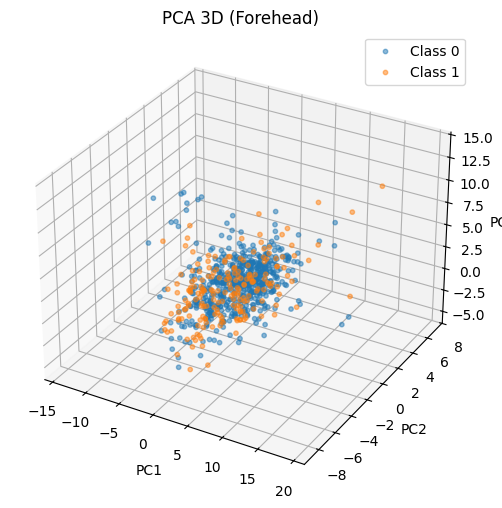

In [14]:
# OPTIONAL PCA 3D
X_all = feat_df_forehead.drop(columns=["label", "path"])
y_all = feat_df_forehead["label"]

X_scaled = StandardScaler().fit_transform(X_all)

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)
print("Explained variance (3D PCA):", pca_3d.explained_variance_ratio_)

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

for lab in [0, 1]:
    sub = X_pca_3d[y_all == lab]
    ax.scatter(sub[:, 0], sub[:, 1], sub[:, 2], s=10, alpha=0.5, label=f"Class {lab}")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA 3D (Forehead)")
ax.legend()
plt.show()

Explained variance (2D PCA): [0.41309921 0.27112138]


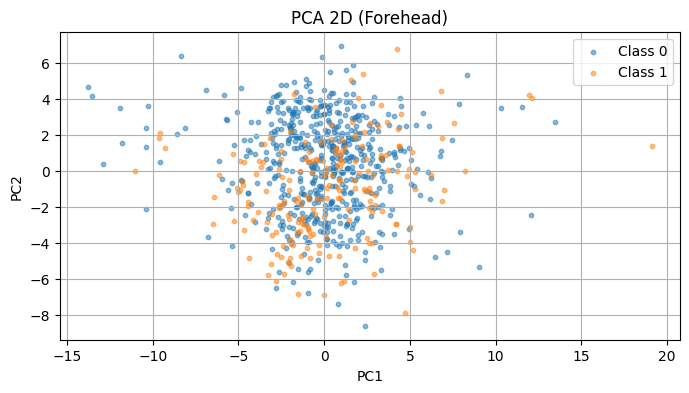

In [15]:
# OPTIONAL PCA 2D
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print("Explained variance (2D PCA):", pca_2d.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
for lab in [0, 1]:
    sub = X_pca_2d[y_all == lab]
    plt.scatter(sub[:, 0], sub[:, 1], s=10, alpha=0.5, label=f"Class {lab}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D (Forehead)")
plt.legend()
plt.grid(True)
plt.show()

              precision    recall  f1-score   support

           0       0.86      0.51      0.64       112
           1       0.36      0.78      0.49        40

    accuracy                           0.58       152
   macro avg       0.61      0.64      0.57       152
weighted avg       0.73      0.58      0.60       152

Confusion Matrix:
 [[57 55]
 [ 9 31]]
Forehead AUC: 0.6928571428571428


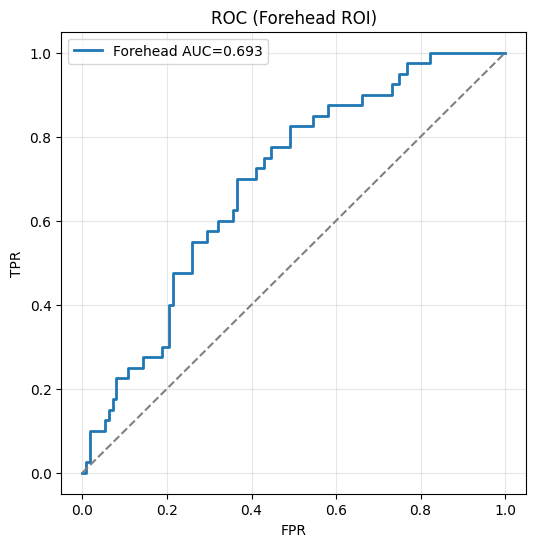

5-Fold CV AUC: [0.55334821 0.65267857 0.68683036 0.68214286 0.56517857]
Mean CV AUC: 0.6280357142857144


In [16]:
# FINAL FOREHEAD MODEL (SVM) + ROC/AUC + 5-FOLD CV
Xsig = feat_df_forehead[sig_feats_forehead]
y = feat_df_forehead["label"]

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))
])

X_train, X_test, y_train, y_test = train_test_split(
    Xsig, y, test_size=0.2, random_state=42, stratify=y
)

svm.fit(X_train, y_train)

pred = svm.predict(X_test)
prob = svm.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

fpr, tpr, _ = roc_curve(y_test, prob)
roc_auc = auc(fpr, tpr)
print("Forehead AUC:", roc_auc)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Forehead AUC={roc_auc:.3f}", linewidth=2)
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC (Forehead ROI)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

cv_auc = cross_val_score(svm, Xsig, y, cv=5, scoring="roc_auc")
print("5-Fold CV AUC:", cv_auc)
print("Mean CV AUC:", cv_auc.mean())

In [17]:
# BRIER SCORE + 95% CI
bs = brier_score_loss(y_test, prob)
print(f"Forehead Brier Score: {bs:.4f}")

n_iterations = 2000
brier_scores_bootstrap = []

for i in range(n_iterations):
    y_res, prob_res = resample(
        np.array(y_test),
        np.array(prob),
        stratify=np.array(y_test),
        random_state=i
    )
    bs_res = brier_score_loss(y_res, prob_res)
    brier_scores_bootstrap.append(bs_res)

lower_brier = np.percentile(brier_scores_bootstrap, 2.5)
upper_brier = np.percentile(brier_scores_bootstrap, 97.5)

print(f"95% CI for Brier Score: [{lower_brier:.4f}, {upper_brier:.4f}]")

Forehead Brier Score: 0.1777
95% CI for Brier Score: [0.1657, 0.1897]


In [18]:
# AUC 95% CI
def auc_bootstrap_ci(y_true, y_prob, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    aucs = []

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    for _ in range(n_boot):
        idx = rng.randint(0, len(y_true), len(y_true))
        y_b = y_true[idx]
        p_b = y_prob[idx]

        if len(np.unique(y_b)) < 2:
            continue

        aucs.append(roc_auc_score(y_b, p_b))

    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)
    return lower, upper

auc_ci_low, auc_ci_high = auc_bootstrap_ci(y_test, prob)
print(f"Forehead Test AUC: {roc_auc:.4f}")
print(f"95% CI for AUC: [{auc_ci_low:.4f}, {auc_ci_high:.4f}]")

Forehead Test AUC: 0.6929
95% CI for AUC: [0.6028, 0.7745]


In [19]:
# YOUDEN THRESHOLD
fpr, tpr, thresholds = roc_curve(y_test, prob)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
youden_thr = thresholds[best_idx]

print(f"Youden threshold: {youden_thr:.4f}")

Youden threshold: 0.2808


In [20]:
# METRICS AT YOUDEN THRESHOLD
y_pred_youden = (np.array(prob) >= youden_thr).astype(int)
cm_youden = confusion_matrix(y_test, y_pred_youden)

tn, fp, fn, tp = cm_youden.ravel()

acc_youden = accuracy_score(y_test, y_pred_youden)
prec_youden = precision_score(y_test, y_pred_youden, zero_division=0)
rec_youden = recall_score(y_test, y_pred_youden, zero_division=0)
spec_youden = tn / (tn + fp)
f1_youden = f1_score(y_test, y_pred_youden, zero_division=0)

print("Forehead — Metrics at Youden threshold")
print(f"Threshold: {youden_thr:.4f}")
print(f"Accuracy: {acc_youden:.4f}")
print(f"Precision: {prec_youden:.4f}")
print(f"Recall: {rec_youden:.4f}")
print(f"Specificity: {spec_youden:.4f}")
print(f"F1-score: {f1_youden:.4f}")
print(f"Confusion matrix: {cm_youden.tolist()}")

Forehead — Metrics at Youden threshold
Threshold: 0.2808
Accuracy: 0.6513
Precision: 0.4058
Recall: 0.7000
Specificity: 0.6339
F1-score: 0.5138
Confusion matrix: [[71, 41], [12, 28]]


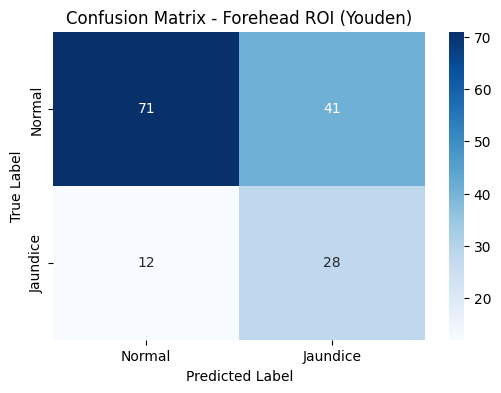

In [21]:
# OPTIONAL: CONFUSION MATRIX HEATMAP (YOUDEN)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_youden, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Normal", "Jaundice"],
    yticklabels=["Normal", "Jaundice"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Forehead ROI (Youden)")
plt.show()

In [22]:
# FINAL TABLE-READY SUMMARY
print("\nFH SVM — Table 1")
print(f"Test AUC: {roc_auc:.4f}")
print(f"95% CI (AUC): [{auc_ci_low:.4f}, {auc_ci_high:.4f}]")
print(f"Brier score: {bs:.4f}")
print(f"95% CI (Brier): [{lower_brier:.4f}, {upper_brier:.4f}]")

print("\nFH SVM — Table 2 (Youden J)")
print("Threshold rule: Youden J")
print(f"Threshold: {youden_thr:.4f}")
print(f"Accuracy: {acc_youden:.4f}")
print(f"Precision: {prec_youden:.4f}")
print(f"Recall: {rec_youden:.4f}")
print(f"Specificity: {spec_youden:.4f}")
print(f"F1-score: {f1_youden:.4f}")
print(f"Confusion matrix: {cm_youden.tolist()}")


FH SVM — Table 1
Test AUC: 0.6929
95% CI (AUC): [0.6028, 0.7745]
Brier score: 0.1777
95% CI (Brier): [0.1657, 0.1897]

FH SVM — Table 2 (Youden J)
Threshold rule: Youden J
Threshold: 0.2808
Accuracy: 0.6513
Precision: 0.4058
Recall: 0.7000
Specificity: 0.6339
F1-score: 0.5138
Confusion matrix: [[71, 41], [12, 28]]


In [23]:
# OPTIONAL: SAVE SUMMARY CSV FILES TO DRIVE
summary_rows = [
    ["FH SVM", float(roc_auc), f"[{auc_ci_low:.4f}, {auc_ci_high:.4f}]", float(bs), f"[{lower_brier:.4f}, {upper_brier:.4f}]"],
]
summary_df = pd.DataFrame(summary_rows, columns=["Approach", "Test AUC", "95% CI (AUC)", "Brier Score", "95% CI (Brier)"])
summary_df.to_csv("/content/drive/MyDrive/FH_SVM_table1_summary.csv", index=False)

screening_rows = [
    ["FH SVM", "Youden J", float(youden_thr), float(acc_youden), float(prec_youden), float(rec_youden), float(spec_youden), float(f1_youden), str(cm_youden.tolist())]
]
screening_df = pd.DataFrame(
    screening_rows,
    columns=["Approach", "Threshold rule", "Threshold", "Accuracy", "Precision", "Recall", "Specificity", "F1-score", "Confusion matrix"]
)
screening_df.to_csv("/content/drive/MyDrive/FH_SVM_table2_summary.csv", index=False)

print("Saved:")
print("/content/drive/MyDrive/FH_SVM_table1_summary.csv")
print("/content/drive/MyDrive/FH_SVM_table2_summary.csv")

Saved:
/content/drive/MyDrive/FH_SVM_table1_summary.csv
/content/drive/MyDrive/FH_SVM_table2_summary.csv
